<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo Final del Máster · Área 1 · Aula 1</p>
<p style="margin: 0; text-align:right;">20241 - Máster universitario en Ciencias de datos (<i>Data science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicaciones</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
    <strong>Estudiante:</strong> James Eward Humberstone Morales
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>El horizonte de predicción para cada clúster sea definido en función del ciclo de aprovisionamiento, entendido como la suma entre el intervalo entre pedidos y el tiempo de entrega (lead time). Se utilizó el valor de la mediana por clúster como estimación operativa, buscando un equilibrio entre la precisión y la aplicabilidad logística.</p>
</div>

In [1]:
!pip install pmdarima scikit_posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.5 MB/s eta 0:00:0000:010:01


In [2]:
# Carga de librerías
import pandas as pd
import numpy as np
import random
import tensorflow as tf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,  mean_absolute_error
from keras.models import Sequential, save_model, load_model
from keras.layers import LSTM, Dense, Input
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
import keras_tuner as kt
from sklearn.model_selection import train_test_split
import joblib
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import scipy.stats as stats 
from scipy.stats import shapiro, levene, kruskal, kstest, norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from scipy.optimize import minimize_scalar
import scikit_posthocs as sp


2025-04-26 03:08:06.108613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745636886.364070      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745636886.435895      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

# 1. Prepraración de los datos

In [3]:
# -----------------------------
# Establecer semilla para reproducibilidad
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
target = "udsVenta"
exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta',
    'cv', 'outlier_rate', 'aprovisionamiento'
]
columnas_modelo = [target] + exogenas
n_lags = 18

In [7]:
# -----------------------------
# CARGAR Y FILTRAR DATOS
# -----------------------------
df_regulares = df[df["cluster_kshape"] == 0].copy()


In [8]:
df_regulares.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438468 entries, 0 to 654407
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           438468 non-null  int64         
 1   idSecuencia        438468 non-null  datetime64[ns]
 2   bolOpen            438468 non-null  int64         
 3   bolHoliday         438468 non-null  int64         
 4   year               438468 non-null  int64         
 5   month              438468 non-null  int64         
 6   day                438468 non-null  int64         
 7   day_of_week        438468 non-null  int64         
 8   week_of_year       438468 non-null  int64         
 9   week_of_month      438468 non-null  int64         
 10  bolPromotion       438468 non-null  int64         
 11  udsVenta           438468 non-null  int64         
 12  median_venta       438468 non-null  int64         
 13  cv                 438468 non-null  float64      

In [9]:
# -----------------------------
# GENERAR SECUENCIAS MULTISERIE
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, df_prod in df_regulares.groupby("producto"):
    df_prod = df_prod.sort_values("idSecuencia")
    
    if len(df_prod) <= n_lags:
        continue  # Saltar si la serie es muy corta

    datos = df_prod[columnas_modelo].copy()

    # Asegurar que aprovisionamiento es constante (replicado si hace falta)
    if "aprovisionamiento" in datos.columns:
        aprov_valor = datos["aprovisionamiento"].iloc[0]
        datos["aprovisionamiento"] = aprov_valor

    # Escalar individualmente
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # udsVenta

    productos_validos += 1

# -----------------------------
# CONVERTIR Y GUARDAR
# -----------------------------
X_total = np.array(X_total)
y_total = np.array(y_total)

np.save("X_lstm_multiserie.npy", X_total)
np.save("y_lstm_multiserie.npy", y_total)

# Guardar columnas usadas
joblib.dump(columnas_modelo, "columnas_modelo_lstm.pkl")

print(f"Dataset generado con éxito")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset generado con éxito
Productos válidos: 599
X shape: (427686, 18, 11) | y shape: (427686,)


# 2. Generar red LSTM

In [10]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_multiserie.npy")
y = np.load("/kaggle/working/y_lstm_multiserie.npy")


In [11]:
# -----------------------------
# CONSTRUIR MODELO PARA TUNING
# -----------------------------
def construir_modelo_lstm(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))  
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3])
        ),
        loss='mse'
    )
    return model

In [12]:
# -----------------------------
# CONFIGURAR KERASTUNER
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_general',
    project_name='lstm_multiserie0',
    seed=SEED
)


I0000 00:00:1744996906.413358      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
# -----------------------------
# ENTRENAMIENTO CON VALIDACIÓN
# -----------------------------
def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X, y,
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Trial 5 Complete [00h 20m 41s]
val_loss: 0.030355772003531456

Best val_loss So Far: 0.030276505276560783
Total elapsed time: 01h 55m 57s


In [14]:
# -----------------------------
# Obtener el mejor modelo y entrenar
# -----------------------------
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.fit(X, y, epochs=30, batch_size=best_hp.get('batch_size'), verbose=1)

Epoch 1/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - loss: 0.0399
Epoch 2/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0382
Epoch 3/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0380
Epoch 4/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0378
Epoch 5/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0377
Epoch 6/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0377
Epoch 7/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0376
Epoch 8/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0375
Epoch 9/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0375
Epoch 10/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0375
Epoch 11/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0374
Epoch 12/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - loss: 0.0374
Epoch 13/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0373
Epoch 14/30
26731/26731 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - 

In [15]:
# Guardar modelo y parámetros
save_model(best_model, "modelo_lstm_general.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_general.pkl")

print("Entrenamiento completado. Modelo y parámetros guardados.")

Entrenamiento completado. Modelo y parámetros guardados.


# 2.1. Calcular la predicción LSTM 

In [16]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
columnas_modelo = joblib.load("/kaggle/working/columnas_modelo_lstm.pkl")
target = columnas_modelo[0]
exogenas = columnas_modelo[1:]
n_lags = 18

In [17]:
# -----------------------------
# CARGAR MODELO LSTM GENERAL
# -----------------------------
modelo = load_model("/kaggle/working/modelo_lstm_general.h5", compile=False)

In [18]:
# -----------------------------
# FUNCIONES
# -----------------------------
def preparar_X_pred(df_producto, columnas, n_lags):
    df_producto = df_producto.sort_values("idSecuencia")
    datos = df_producto[columnas].copy()

    # Replicar aprovisionamiento si es constante
    if "aprovisionamiento" in datos.columns:
        datos["aprovisionamiento"] = datos["aprovisionamiento"].iloc[0]

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    if len(datos_scaled) <= n_lags:
        return None, None, None, None

    X_pred = [datos_scaled[i - n_lags:i] for i in range(n_lags, len(datos_scaled))]
    fechas = df_producto["idSecuencia"].iloc[n_lags:].values
    y_real = df_producto[target].iloc[n_lags:].values

    return np.array(X_pred), fechas, y_real, scaler

def desescalar_predicciones(pred_scaled, scaler, n_exogenas):
    datos_completos = np.concatenate(
        [pred_scaled, np.zeros((len(pred_scaled), n_exogenas))], axis=1
    )
    return scaler.inverse_transform(datos_completos)[:, 0]

In [19]:
# -----------------------------
# PREDICCIÓN PARA TODAS LAS SERIES
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_regulares['producto'].unique()

resultados = []

for producto_id, df_producto in tqdm(df_regulares.groupby("producto")):
    X_pred, fechas, y_real, scaler_local = preparar_X_pred(df_producto, columnas_modelo, n_lags)
    if X_pred is None:
        continue

    y_pred_scaled = modelo.predict(X_pred, verbose=0)
    y_pred = desescalar_predicciones(y_pred_scaled, scaler_local, len(exogenas))

    df_resultado = pd.DataFrame({
        'producto': producto_id,
        'fecha': fechas,
        'valor_real': y_real,
        'valor_predicho': y_pred,
        'metodo': 'LSTM',
        'kmeans': -1
    })
    resultados.append(df_resultado)

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 599/599 [01:06<00:00,  8.96it/s]


 Predicciones finalizadas en 66.88 segundos.


In [20]:
# Concatenar resultados y exportar
df_predicciones_lstm_general = pd.concat(resultados, ignore_index=True)
df_predicciones_lstm_general.to_csv("predicciones_lstm_general.csv", index=False)

# 2.2 Visualizaciones

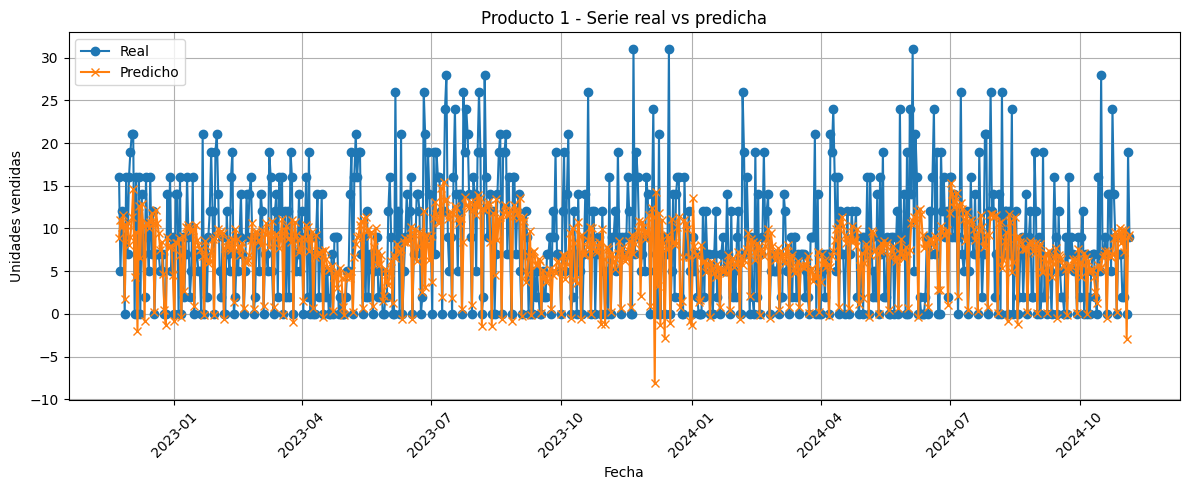

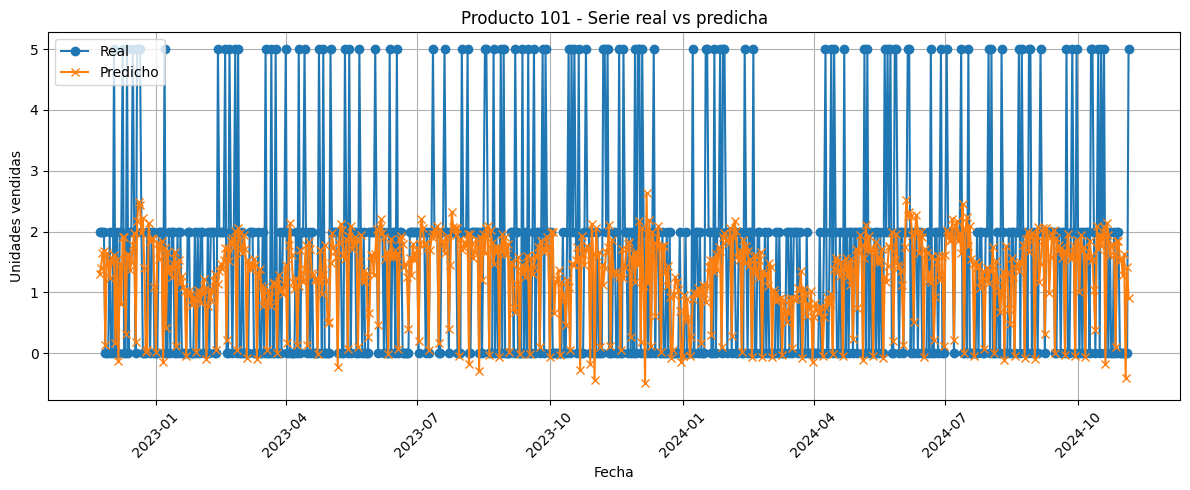

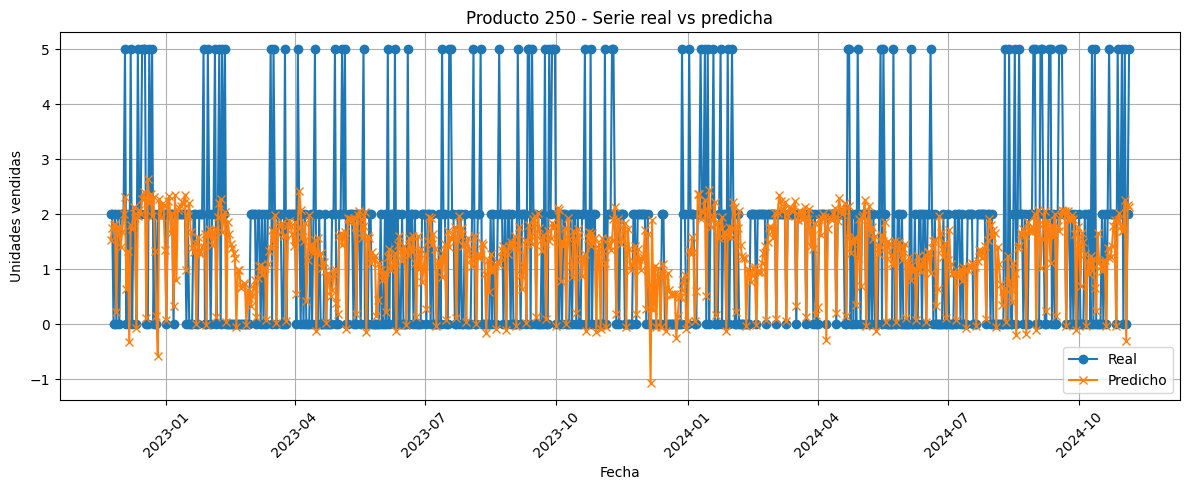

In [21]:
productos_ejemplo = [1, 101, 250]

for producto_id in productos_ejemplo:
    df_prod = df_predicciones_lstm_general[df_predicciones_lstm_general['producto'] == producto_id]
    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_producto_{producto_id}.png")
    plt.show()

In [22]:
# Calcular RMSE por producto
rmse_por_producto = (
    df_predicciones_lstm_general[['producto', 'valor_real', 'valor_predicho']]
    .groupby("producto")[['valor_real', 'valor_predicho']]
    .apply(lambda g: np.sqrt(np.mean((g['valor_real'] - g['valor_predicho']) ** 2)))
    .reset_index(name="RMSE")
)

print(rmse_por_producto.describe())

          producto        RMSE
count   599.000000  599.000000
mean    442.208681    2.169056
std     290.212501    0.675043
min       1.000000    0.748191
25%     185.500000    1.682687
50%     411.000000    2.068240
75%     675.500000    2.611290
max    1000.000000    6.000308


In [23]:
# RMSE global
rmse_global = np.sqrt(np.mean((df_predicciones_lstm_general['valor_real'] - df_predicciones_lstm_general['valor_predicho']) ** 2))
print(f"RMSE global del modelo LSTM generalizado: {rmse_global:.4f}")

RMSE global del modelo LSTM generalizado: 2.2715


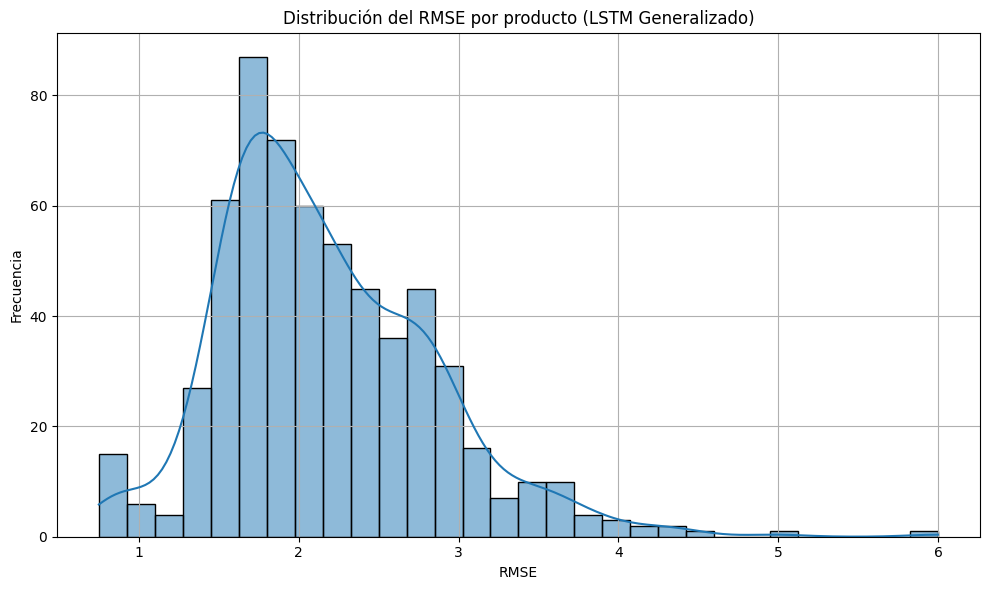

In [24]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(10, 6))
sns.histplot(rmse_por_producto['RMSE'], bins=30, kde=True)
plt.title("Distribución del RMSE por producto (LSTM Generalizado)")
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.savefig("histograma_rmse_lstm.png")
plt.show()

# 3. Aplicar el modelo ARIMA

In [4]:
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

In [5]:
df_regulares = df[df["cluster_kshape"] == 0].copy()

In [10]:
df_regulares.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438468 entries, 0 to 654407
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           438468 non-null  int64         
 1   idSecuencia        438468 non-null  datetime64[ns]
 2   bolOpen            438468 non-null  int64         
 3   bolHoliday         438468 non-null  int64         
 4   year               438468 non-null  int64         
 5   month              438468 non-null  int64         
 6   day                438468 non-null  int64         
 7   day_of_week        438468 non-null  int64         
 8   week_of_year       438468 non-null  int64         
 9   week_of_month      438468 non-null  int64         
 10  bolPromotion       438468 non-null  int64         
 11  udsVenta           438468 non-null  int64         
 12  median_venta       438468 non-null  int64         
 13  cv                 438468 non-null  float64      

In [5]:
# -----------------------------
# Configuración
# -----------------------------
n_test = 18  # horizonte de predicción
col_serie = "udsVenta"

In [6]:
# -----------------------------
# Función para ajustar ARIMA por producto
# -----------------------------
def ajustar_arima_producto(df_producto, col_serie="udsVenta", n_test=18):
    df_producto = df_producto.sort_values("idSecuencia")
    serie = df_producto[col_serie].values

    if len(serie) <= n_test + 10:
        return None  # muy corta para entrenar

    try:
        # 1. Determinar orden ARIMA automáticamente
        modelo_auto = auto_arima(serie[:-n_test], seasonal=False,
                                 error_action='ignore', suppress_warnings=True,
                                 max_p=5, max_q=5, max_d=2, stepwise=True)
        orden = modelo_auto.order

        # 2. Ajustar ARIMA final
        modelo = ARIMA(serie[:-n_test], order=orden)
        modelo_fit = modelo.fit()

        # 3. Predecir y calcular residuos
        y_pred = modelo_fit.predict(start=len(serie) - n_test, end=len(serie) - 1)
        y_real = serie[-n_test:]
        residuos = y_real - y_pred

        return {
            "orden": orden,
            "y_pred": y_pred,
            "residuos": residuos,
            "y_real": y_real,
            "modelo_fit": modelo_fit
        }

    except Exception as e:
        print(f"Error en producto {df_producto['producto'].iloc[0]}: {e}")
        return None

In [7]:
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters")
warnings.simplefilter("ignore", ConvergenceWarning)

In [8]:
# -----------------------------
# Aplicar a todos los productos regulares
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_regulares['producto'].unique()

resultados_arima = {}
for producto_id, df_prod in tqdm(df_regulares.groupby("producto")):
    resultado = ajustar_arima_producto(df_prod, col_serie=col_serie, n_test=n_test)
    if resultado is not None:
        resultados_arima[producto_id] = resultado

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 599/599 [1:03:47<00:00,  6.39s/it]


 Predicciones finalizadas en 3827.62 segundos.


In [9]:
# -----------------------------
# Guardar resultados
# -----------------------------
joblib.dump(resultados_arima, "resultados_arima_599.pkl")
print(f"ARIMA ajustado para {len(resultados_arima)} productos.")


ARIMA ajustado para 599 productos.


In [6]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

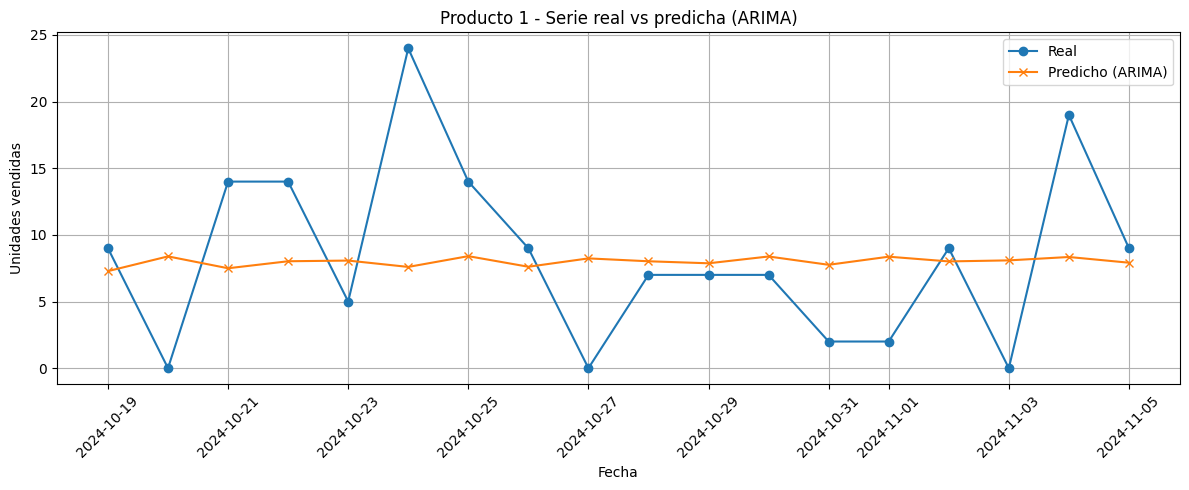

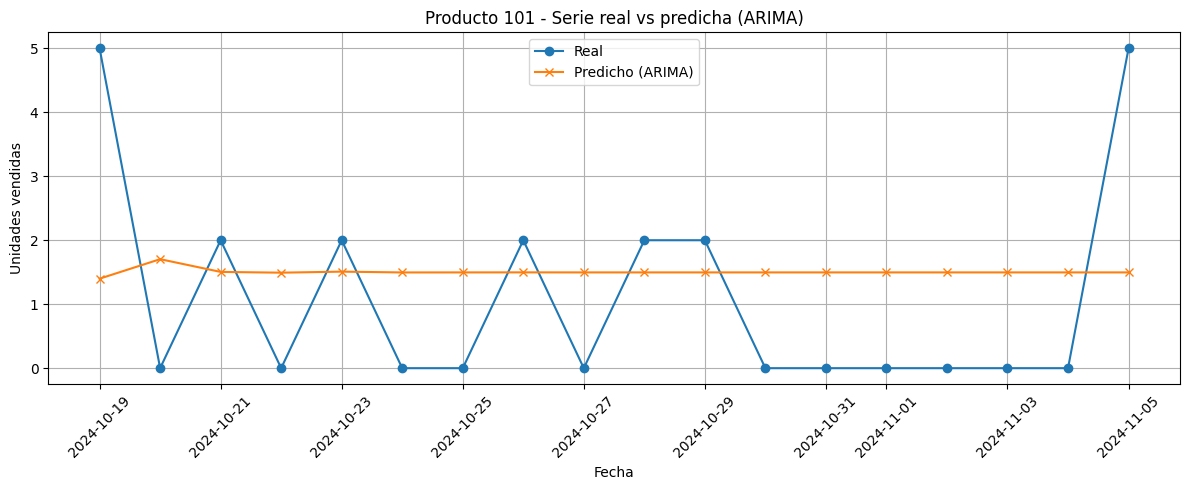

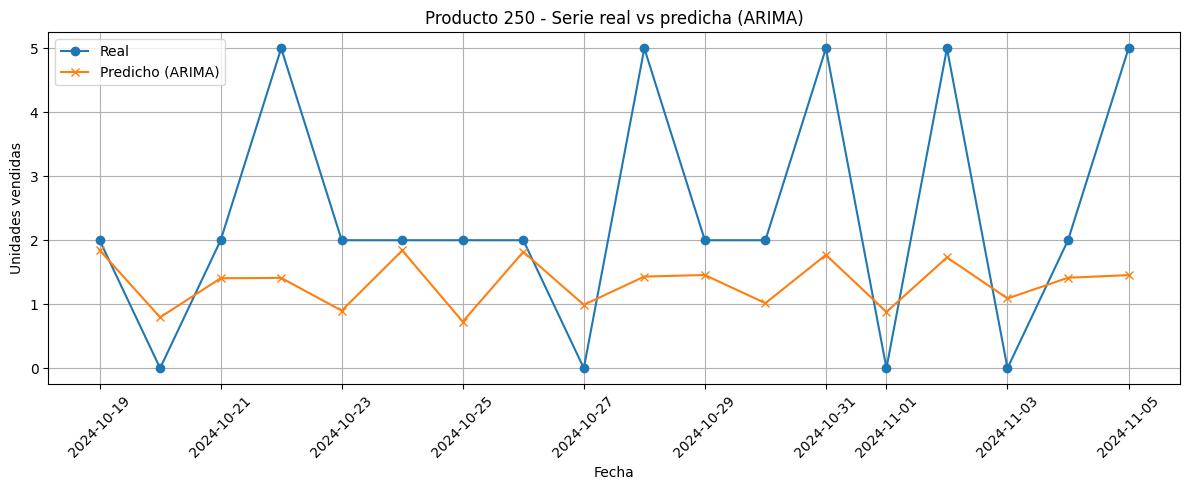

In [11]:
productos_ejemplo = [1, 101, 250] 

for producto_id in productos_ejemplo:
    resultado = resultados_arima[producto_id]
    
    y_real = resultado["y_real"]
    y_pred = resultado["y_pred"]
    
    
    # Verificar si hay datos del producto en el DataFrame
    df_producto = df_regulares[df_regulares['producto'] == producto_id].copy()

    if not df_producto.empty:
        fechas_disponibles = df_producto['idSecuencia'].reset_index(drop=True)
        # Ajustamos el número de fechas a la longitud de y_real
        if len(fechas_disponibles) >= len(y_real):
            fechas = fechas_disponibles.iloc[-len(y_real):].reset_index(drop=True)
        else:
            raise ValueError(f"El número de fechas disponibles ({len(fechas_disponibles)}) es menor que la longitud de y_real ({len(y_real)}) para el producto {producto_id}")
    else:
        raise ValueError(f"No se encontraron datos en df_regulares para el producto {producto_id}")

    # Crear DataFrame para trazado
    df_plot = pd.DataFrame({
        'fecha': fechas,
        'Real': y_real,
        'Predicho': y_pred
    })

    # Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot['fecha'], df_plot['Real'], label='Real', marker='o')
    plt.plot(df_plot['fecha'], df_plot['Predicho'], label='Predicho (ARIMA)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (ARIMA)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_arima_producto_{producto_id}.png")
    plt.show()

# 4. Modelo híbrido paralelo

In [65]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [66]:
# --- Cargar base original para obtener fechas ---
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

# Asegurarnos que las fechas estén ordenadas por producto y por secuencia
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [67]:
# --- Cargar predicciones LSTM ---
df_lstm = pd.read_csv("/kaggle/working/predicciones_lstm_general.csv")

In [68]:
# Crear diccionario para fechas por producto (últimos N puntos según cada serie ARIMA)
fechas_por_producto = {}
for producto_id in resultados_arima.keys():
    n_puntos = len(resultados_arima[producto_id]["y_real"])
    fechas = df_base[df_base["producto"] == producto_id]["idSecuencia"].iloc[-n_puntos:].reset_index(drop=True)
    fechas_por_producto[producto_id] = fechas


In [69]:
# --- Calcular combinación ponderada ARIMA + LSTM ---
resultados_paralelo_ponderado = []

for producto_id in resultados_arima.keys():
    arima_data = resultados_arima[producto_id]
    y_pred_arima = np.array(arima_data["y_pred"])
    y_real = np.array(arima_data["y_real"])

    # Obtener fechas correspondientes
    fechas = fechas_por_producto[producto_id]

    # LSTM: filtrar y alinear
    df_lstm_prod = df_lstm[df_lstm['producto'] == producto_id].copy()
    if len(df_lstm_prod) >= len(y_pred_arima):
        y_pred_lstm = df_lstm_prod['valor_predicho'].values[-len(y_pred_arima):]
        y_real_lstm = df_lstm_prod['valor_real'].values[-len(y_pred_arima):]

        # Verificación (opcional)
        if not np.allclose(y_real, y_real_lstm):
            print(f"[!] Warning: diferencias en y_real para producto {producto_id}, se usará y_real de ARIMA.")

        # --- Optimizar peso ---
        def calcular_rmse_ponderado(w_arima, y_arima, y_lstm, y_real):
            y_comb = w_arima * y_arima + (1 - w_arima) * y_lstm
            return mean_squared_error(y_real, y_comb, squared=False)

        resultado = minimize_scalar(
            calcular_rmse_ponderado,
            bounds=(0, 1),
            args=(y_pred_arima, y_pred_lstm, y_real),
            method='bounded'
        )

        w_optimo = resultado.x
        rmse_optimo = resultado.fun
        y_comb = w_optimo * y_pred_arima + (1 - w_optimo) * y_pred_lstm
        mae = mean_absolute_error(y_real, y_comb)
        mape = np.mean(np.abs((y_real - y_comb) / np.maximum(y_real, 1))) * 100

        # Guardar resultados
        for fecha, real, pred in zip(fechas, y_real, y_comb):
            resultados_paralelo_ponderado.append({
                "producto": producto_id,
                "fecha": fecha,
                "valor_real": real,
                "valor_predicho": pred,
                "w_arima": round(w_optimo, 3),
                "w_lstm": round(1 - w_optimo, 3),
                "rmse": rmse_optimo,
                "mae": mae,
                "mape": mape,
                "modelo": "paralelo_ponderado"
            })
    else:
        print(f"LSTM no tiene suficientes datos para producto {producto_id}")

# Convertir a DataFrame
df_resultados_paralelo_ponderado = pd.DataFrame(resultados_paralelo_ponderado)

In [70]:
df_resultados_paralelo_ponderado.head()

,producto,fecha,valor_real,valor_predicho,w_arima,w_lstm,rmse,mae,mape,modelo
0,1,2024-10-19,9,7.349998,0.223,0.777,5.845818,4.032099,80.170215,paralelo_ponderado
1,1,2024-10-20,0,1.475236,0.223,0.777,5.845818,4.032099,80.170215,paralelo_ponderado
2,1,2024-10-21,14,7.417513,0.223,0.777,5.845818,4.032099,80.170215,paralelo_ponderado
3,1,2024-10-22,14,7.055023,0.223,0.777,5.845818,4.032099,80.170215,paralelo_ponderado
4,1,2024-10-23,5,6.945435,0.223,0.777,5.845818,4.032099,80.170215,paralelo_ponderado


In [71]:
df_resultados_paralelo_ponderado.to_csv("predicciones_ponderado.csv", index=False)

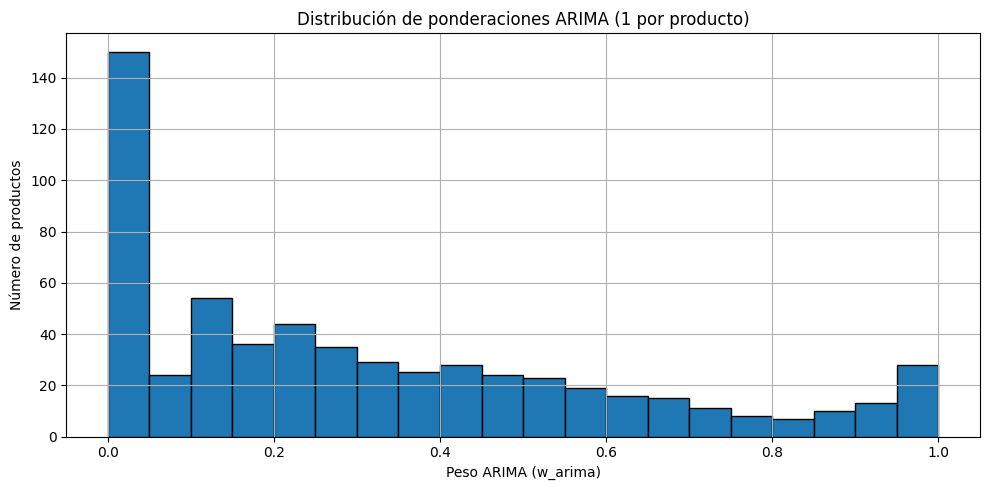

In [18]:
df_pesos_unicos = df_resultados_paralelo_ponderado.drop_duplicates(subset="producto")


plt.figure(figsize=(10, 5))
plt.hist(df_pesos_unicos["w_arima"], bins=20, edgecolor='black')
plt.title("Distribución de ponderaciones ARIMA (1 por producto)")
plt.xlabel("Peso ARIMA (w_arima)")
plt.ylabel("Número de productos")
plt.grid(True)
plt.tight_layout()
plt.show()

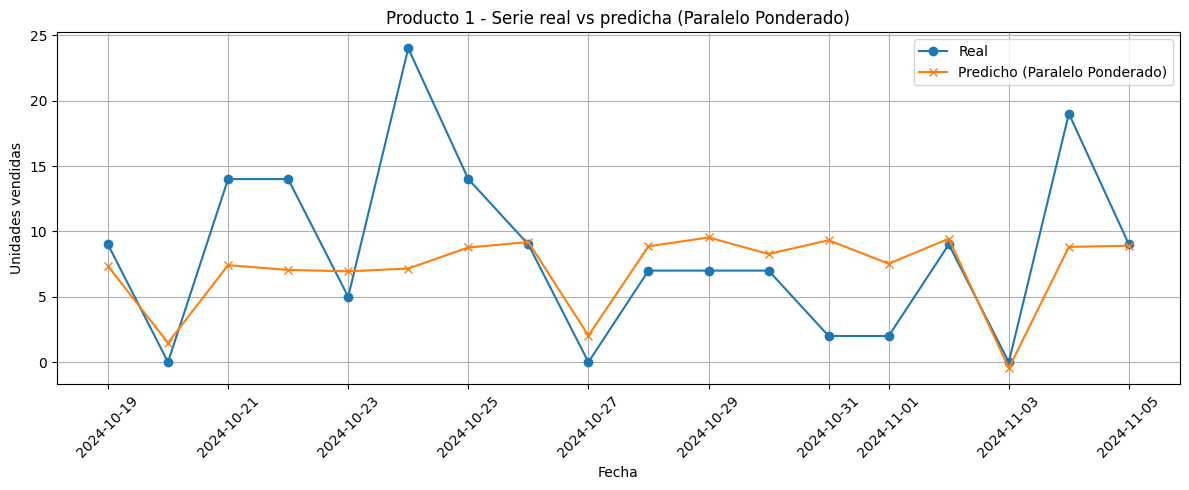

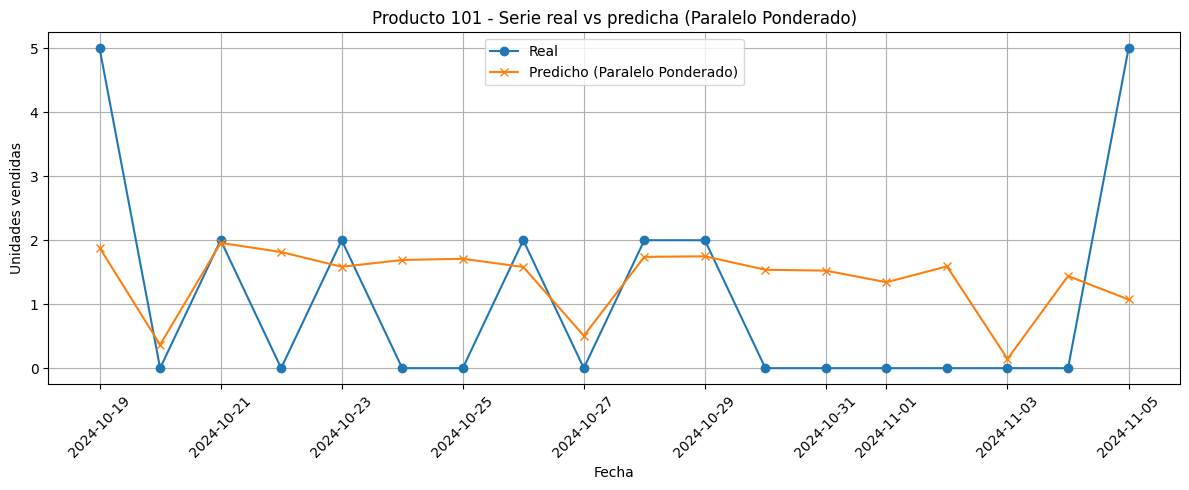

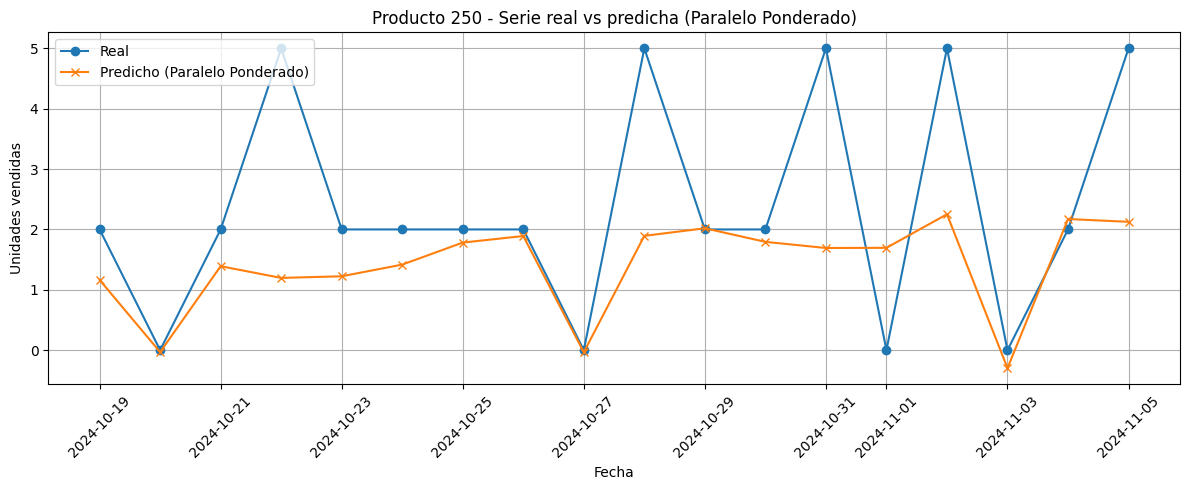

In [19]:
productos_ejemplo = [1, 101, 250] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_paralelo_ponderado[df_resultados_paralelo_ponderado['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Paralelo Ponderado)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Paralelo Ponderado)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_paralelo_ponderado_producto_{producto_id}.png")
    plt.show()


# 5. Modelo híbrido secuencial

In [17]:
# -----------------------------
# PARÁMETROS
# -----------------------------
n_lags = 1  # número de pasos para la secuencia
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_objetivo = 'residuo'
columnas_modelo = [columna_objetivo] + columnas_exogenas

In [5]:
# --- Cargar base original para obtener fechas ---
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

df_base = df[df["cluster_kshape"] == 0].copy()

df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

## 5.1 Cargar predicciones y residuos de ARIMA

In [6]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [7]:
productos_base = set(df_base['producto'].unique())
productos_arima = set(resultados_arima.keys())
productos_comunes = productos_base & productos_arima

print(f"Productos comunes: {len(productos_comunes)}")


Productos comunes: 599


In [18]:
# -----------------------------
# CREAR DATASET MULTISERIE CON RESIDUOS
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred

    # Extraer las 18 filas correspondientes en base original
    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) < n_lags:
        continue  # no se puede formar ni una secuencia

    df_prod["residuo"] = residuos

    # Mantener aprovisionamiento constante si aplica
    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    # Escalar por producto
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    # Rolling window para los 18 puntos
    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # residuo_t

    productos_validos += 1


In [19]:
X_total = np.array(X_total)
y_total = np.array(y_total)

# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
np.save("X_lstm_residuos_rolling.npy", X_total)
np.save("y_lstm_residuos_rolling.npy", y_total)
joblib.dump(columnas_modelo, "columnas_modelo_residuos.pkl")

['columnas_modelo_residuos.pkl']

In [20]:
# Reporte
print(f"Dataset generado exitosamente")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset generado exitosamente
Productos válidos: 599
X shape: (10183, 1, 11) | y shape: (10183,)


# 5.2 Aplicar red LSTM sobre residuos

In [21]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_residuos_rolling.npy")
y = np.load("/kaggle/working/y_lstm_residuos_rolling.npy")

In [24]:
# -----------------------------
# DIVISIÓN TRAIN/VALIDACIÓN
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)

In [28]:
# -----------------------------
# DEFINIR FUNCIÓN DE MODELO
# -----------------------------
def construir_modelo_lstm(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))

    # Unidades en LSTM
    units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(LSTM(units=units, activation='tanh'))
    model.add(Dense(1))

    # Tasa de aprendizaje
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=MeanSquaredError(), metrics=['mae'])
    return model

In [29]:
# -----------------------------
# CONFIGURAR RANDOM SEARCH
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_residuos',
    project_name='lstm_residuos_n1',
    seed=SEED
)

In [30]:
# -----------------------------
# ENTRENAMIENTO DEL TUNER
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    callbacks=[early_stop],
    verbose=1
)



Trial 5 Complete [00h 01m 49s]
val_loss: 0.11066843569278717

Best val_loss So Far: 0.10732471942901611
Total elapsed time: 00h 09m 05s


In [31]:
# -----------------------------
# EXTRAER MEJORES PARÁMETROS
# -----------------------------
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("🔎 Mejores hiperparámetros encontrados:")
print(f"Units: {best_hp.get('units')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")


🔎 Mejores hiperparámetros encontrados:
Units: 32
Learning Rate: 0.005977728042983696


In [32]:
# -----------------------------
# ENTRENAR MODELO FINAL
# -----------------------------
modelo_final = tuner.hypermodel.build(best_hp)

modelo_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_hp.get('batch_size'),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1285 - mae: 0.2910 - val_loss: 0.1187 - val_mae: 0.2615
Epoch 2/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1185 - mae: 0.2776 - val_loss: 0.1152 - val_mae: 0.2637
Epoch 3/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1171 - mae: 0.2753 - val_loss: 0.1131 - val_mae: 0.2648
Epoch 4/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1161 - mae: 0.2737 - val_loss: 0.1120 - val_mae: 0.2652
Epoch 5/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1156 - mae: 0.2731 - val_loss: 0.1113 - val_mae: 0.2660
Epoch 6/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1153 - mae: 0.2727 - val_loss: 0.1109 - val_mae: 0.2667
Epoch 7/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1150 - mae: 0.2722 - val_loss: 0.1105 - val_mae: 0.2671
Epoch 8/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1147 - mae: 0.2717 - val_loss: 0.1101 - val_mae: 0.2672
Epoch 9/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

In [34]:
# -----------------------------
# GUARDAR MODELO FINAL
# -----------------------------
modelo_final.save("modelo_lstm_residuos_n1_tuned.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_residuos.pkl")
print("Modelo LSTM (residuos) entrenado y guardado")

Modelo LSTM (residuos) entrenado y guardado


## 5.3 Calculo de los residuos

In [4]:
# -----------------------------
# CARGAR RECURSOS NECESARIOS
# -----------------------------
# Modelo entrenado
modelo_lstm = load_model("/kaggle/working/modelo_lstm_residuos_n1_tuned.h5")

# Columnas del modelo
columnas_modelo = joblib.load("/kaggle/working/columnas_modelo_residuos.pkl")

I0000 00:00:1745200349.199065      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
# Resultados ARIMA
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [6]:
# Dataset original base
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

df_base = df_base[df_base["cluster_kshape"] == 0].copy()

df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [7]:
# -----------------------------
# PARÁMETROS DEL MODELO
# -----------------------------
n_lags = 1

In [8]:
# -----------------------------
# GENERAR PREDICCIONES SEC. HÍBRIDO
# -----------------------------
resultados_secuencial = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred_arima = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred_arima

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["residuo"] = residuos
    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"[!] Producto {producto_id} omitido por columnas faltantes: {e}")
        continue

    # Escalar datos
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    fechas = df_prod["idSecuencia"].iloc[n_lags:].reset_index(drop=True)
    y_real_final = y_real[n_lags:]
    y_pred_arima_final = y_pred_arima[n_lags:]

    for i in range(n_lags, len(datos_scaled)):
        X_input = datos_scaled[i - n_lags:i].reshape(1, n_lags, len(columnas_modelo))
        pred_residuo = modelo_lstm.predict(X_input, verbose=0)[0][0]
        y_pred_hibrido = y_pred_arima[i] + pred_residuo

        resultados_secuencial.append({
            "producto": producto_id,
            "fecha": fechas[i - n_lags],
            "valor_real": y_real[i],
            "valor_predicho": y_pred_hibrido,
            "modelo": "secuencial"
        })

I0000 00:00:1745200613.249833     108 cuda_dnn.cc:529] Loaded cuDNN version 90300


In [14]:
# Convertir a DataFrame
df_resultados_secuencial = pd.DataFrame(resultados_secuencial)

In [16]:
# Calcular métricas por producto
metricas = df_resultados_secuencial.groupby("producto")[["valor_real", "valor_predicho"]].apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    })
).reset_index()



# Unir métricas al resultado
df_resultados_secuencial = df_resultados_secuencial.merge(metricas, on="producto")

In [17]:
df_resultados_secuencial.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,1,2024-10-20,0,8.404204,secuencial,6.707506,5.324393,206.291921
1,1,2024-10-21,14,7.811780,secuencial,6.707506,5.324393,206.291921
2,1,2024-10-22,14,8.391085,secuencial,6.707506,5.324393,206.291921
3,1,2024-10-23,5,8.442771,secuencial,6.707506,5.324393,206.291921
4,1,2024-10-24,24,7.882772,secuencial,6.707506,5.324393,206.291921


In [18]:
df_resultados_secuencial.to_csv("predicciones_secuencial.csv", index=False)

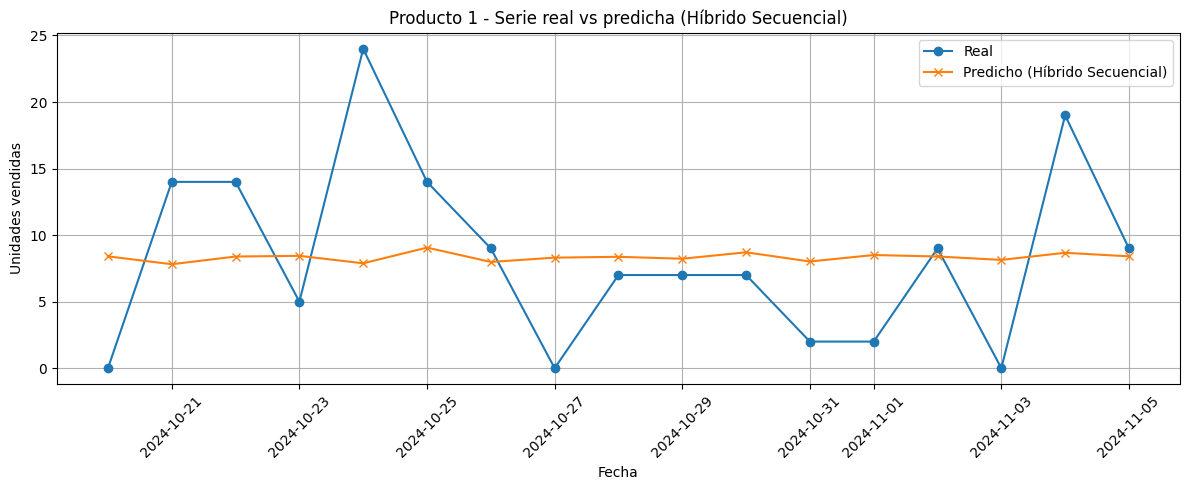

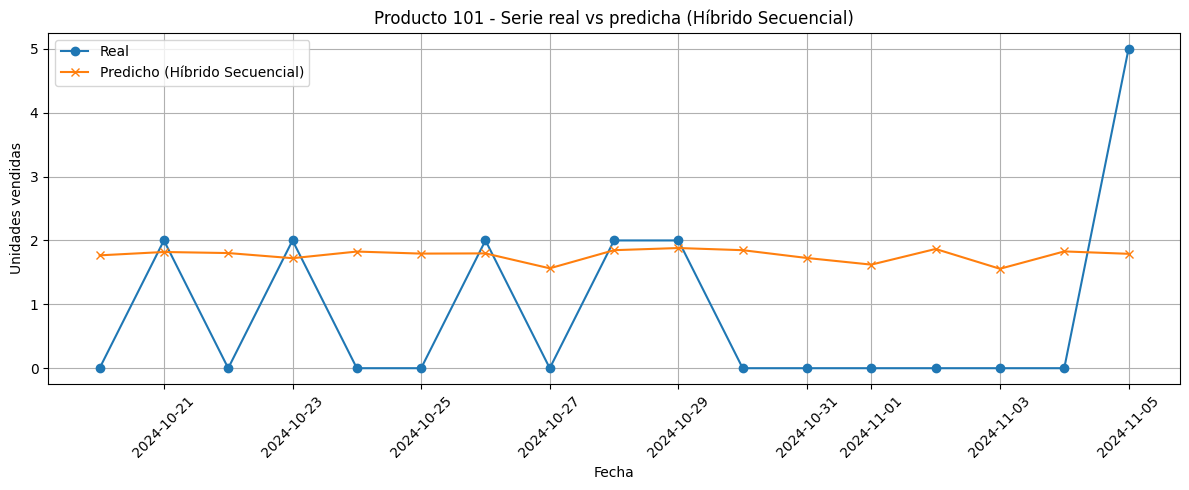

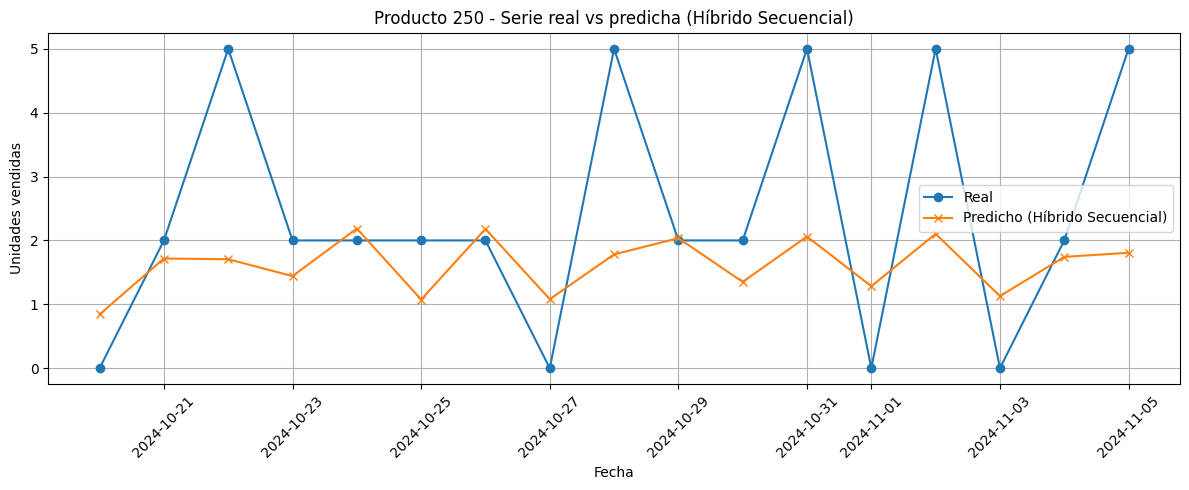

In [19]:
productos_ejemplo = [1, 101, 250] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_secuencial[df_resultados_secuencial['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Híbrido Secuencial)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Híbrido Secuencial)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_secuencial_producto_{producto_id}.png")
    plt.show()


# 6. Modelo híbrido integrado

In [28]:
# -----------------------------
# PARÁMETROS
# -----------------------------
n_lags = 1
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_arima = 'y_pred_arima'
columna_residuo = 'residuo_arima'
columna_objetivo = 'udsVenta'
columnas_modelo = [columna_objetivo] + [columna_arima, columna_residuo] + columnas_exogenas

In [29]:
# -----------------------------
# CARGAR BASES
# -----------------------------
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df[df["cluster_kshape"] == 0].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

## 6.1 Cargar predicciones y residuos de ARIMA

In [22]:
# Cargar predicciones ARIMA
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [23]:
# -----------------------------
# GENERAR SECUENCIAS MULTIVARIADAS
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["udsVenta"] = y_real
    df_prod["y_pred_arima"] = y_pred
    df_prod["residuo_arima"] = residuos

    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # objetivo: udsVenta

    productos_validos += 1

In [24]:
# Convertir a arrays
X_total = np.array(X_total)
y_total = np.array(y_total)

Dataset para modelo híbrido integrado generado con éxito
Productos válidos: 599
X shape: (10183, 1, 13) | y shape: (10183,)


In [ ]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
np.save("X_lstm_integrado.npy", X_total)
np.save("y_lstm_integrado.npy", y_total)
joblib.dump(columnas_modelo, "columnas_modelo_integrado.pkl")

In [ ]:
print("Dataset para modelo híbrido integrado generado con éxito")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

## 6.2 Entrenamiento de LSTM

In [39]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_integrado.npy")
y = np.load("/kaggle/working/y_lstm_integrado.npy")

In [40]:
# -----------------------------
# DIVISIÓN TRAIN/VALIDACIÓN
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)

In [41]:
# -----------------------------
# DEFINIR FUNCIÓN DE MODELO
# -----------------------------
def construir_modelo_lstm_integrado(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))

    units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(LSTM(units=units, activation='tanh'))
    model.add(Dense(1))

    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=MeanSquaredError(), metrics=['mae'])
    return model

In [43]:
# -----------------------------
# CONFIGURAR RANDOM SEARCH
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm_integrado,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_integrado',
    project_name='lstm_integrado_n2',
    seed=SEED
)

In [44]:
# -----------------------------
# ENTRENAMIENTO DEL TUNER
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 01m 50s]
val_loss: 0.11618591099977493

Best val_loss So Far: 0.11267831921577454
Total elapsed time: 00h 09m 06s


In [45]:
# -----------------------------
# EXTRAER MEJORES PARÁMETROS
# -----------------------------
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("🔎 Mejores hiperparámetros encontrados:")
print(f"Units: {best_hp.get('units')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")

🔎 Mejores hiperparámetros encontrados:
Units: 32
Learning Rate: 0.005977728042983696


In [46]:
# -----------------------------
# ENTRENAR MODELO FINAL
# -----------------------------
modelo_final = tuner.hypermodel.build(best_hp)

modelo_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_hp.get('batch_size'),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1312 - mae: 0.2949 - val_loss: 0.1251 - val_mae: 0.2681
Epoch 2/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1239 - mae: 0.2821 - val_loss: 0.1209 - val_mae: 0.2702
Epoch 3/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1224 - mae: 0.2800 - val_loss: 0.1188 - val_mae: 0.2714
Epoch 4/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1216 - mae: 0.2789 - val_loss: 0.1176 - val_mae: 0.2717
Epoch 5/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1212 - mae: 0.2783 - val_loss: 0.1169 - val_mae: 0.2718
Epoch 6/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1208 - mae: 0.2778 - val_loss: 0.1164 - val_mae: 0.2717
Epoch 7/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1205 - mae: 0.2774 - val_loss: 0.1159 - val_mae: 0.2713
Epoch 8/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1201 - mae: 0.2769 - val_loss: 0.1154 - val_mae: 0.2708
Epoch 9/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

In [47]:
# -----------------------------
# GUARDAR MODELO FINAL
# -----------------------------
modelo_final.save("modelo_lstm_integrado_n1_tuned.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_integrado.pkl")
print("Modelo LSTM híbrido integrado guardado")

Modelo LSTM híbrido integrado guardado


## 6.3 Cálculo de la demanda

In [48]:
# -----------------------------
# CARGAR MODELO ENTRENADO
# -----------------------------
modelo_integrado = load_model("modelo_lstm_integrado_n1_tuned.h5")

In [49]:
# -----------------------------
# CARGAR BASE Y RESULTADOS ARIMA
# -----------------------------
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df_base[df_base["cluster_kshape"] == 0].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [50]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [51]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_objetivo = 'udsVenta'
columnas_modelo = [columna_objetivo, 'y_pred_arima', 'residuo_arima'] + columnas_exogenas
n_lags = 1


In [52]:
# -----------------------------
# PREDECIR 17 PUNTOS POR PRODUCTO
# -----------------------------
resultados_integrado = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred_arima = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred_arima

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["udsVenta"] = y_real
    df_prod["y_pred_arima"] = y_pred_arima
    df_prod["residuo_arima"] = residuos

    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    fechas = df_prod["idSecuencia"].values[n_lags:]
    reales = datos.values[n_lags:, 0]

    for i in range(n_lags, len(datos_scaled)):
        X_input = datos_scaled[i - n_lags:i].reshape(1, n_lags, len(columnas_modelo))
        y_pred = modelo_integrado.predict(X_input, verbose=0)[0][0]

        resultados_integrado.append({
            "producto": producto_id,
            "fecha": fechas[i - n_lags],
            "valor_real": reales[i - n_lags],
            "valor_predicho": y_pred,
            "modelo": "integrado"
        })

In [58]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_integrado = pd.DataFrame(resultados_integrado)

# Calcular métricas por fila
#df_resultados_integrado["error_abs"] = np.abs(df_resultados_integrado["valor_real"] - df_resultados_integrado["valor_predicho"])
#df_resultados_integrado["error_pct"] = df_resultados_integrado["error_abs"] / np.maximum(df_resultados_integrado["valor_real"], 1)
#df_resultados_integrado["mape"] = df_resultados_integrado["error_pct"] * 100


In [61]:
# Calcular métricas por producto y asignar
metricas = df_resultados_integrado.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

df_resultados_integrado = df_resultados_integrado.merge(metricas, on="producto", how="left")


In [62]:
df_resultados_integrado.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,1,2024-10-20,0.0,-0.061761,integrado,10.433226,8.08626,79.348242
1,1,2024-10-21,14.0,0.309933,integrado,10.433226,8.08626,79.348242
2,1,2024-10-22,14.0,0.308810,integrado,10.433226,8.08626,79.348242
3,1,2024-10-23,5.0,0.321787,integrado,10.433226,8.08626,79.348242
4,1,2024-10-24,24.0,0.275056,integrado,10.433226,8.08626,79.348242


In [63]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
df_resultados_integrado.to_csv("resultados_modelo_integrado.csv", index=False)

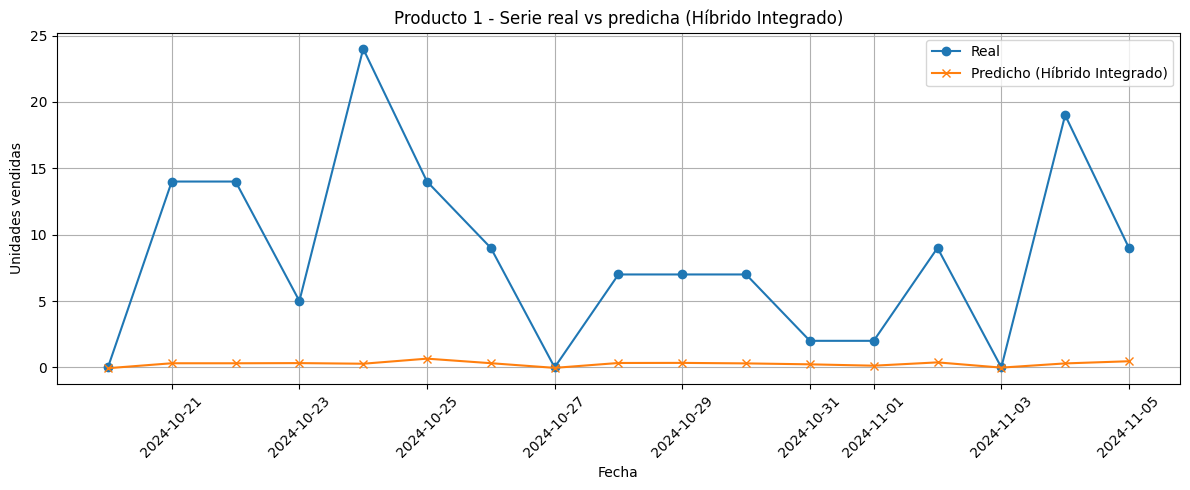

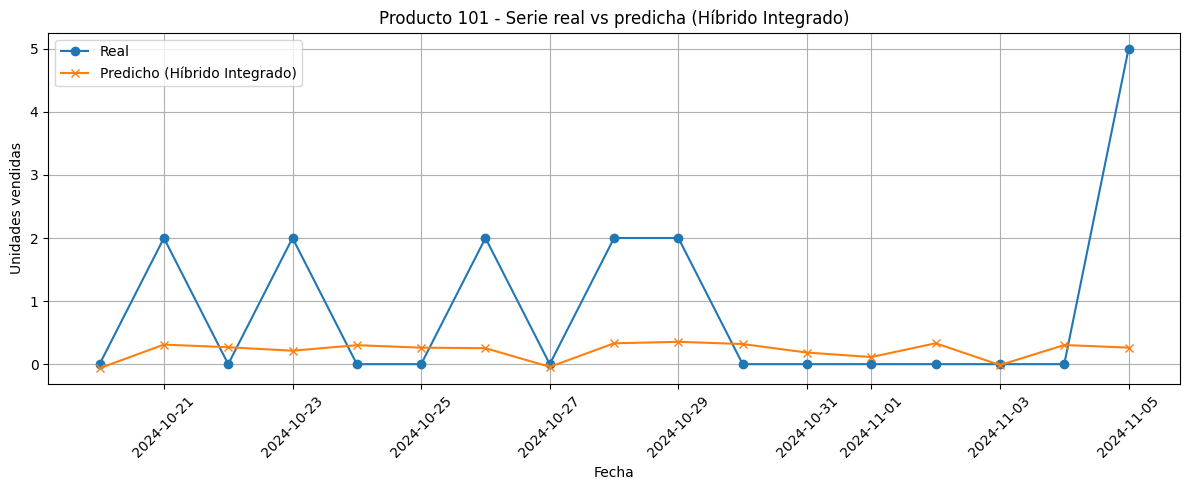

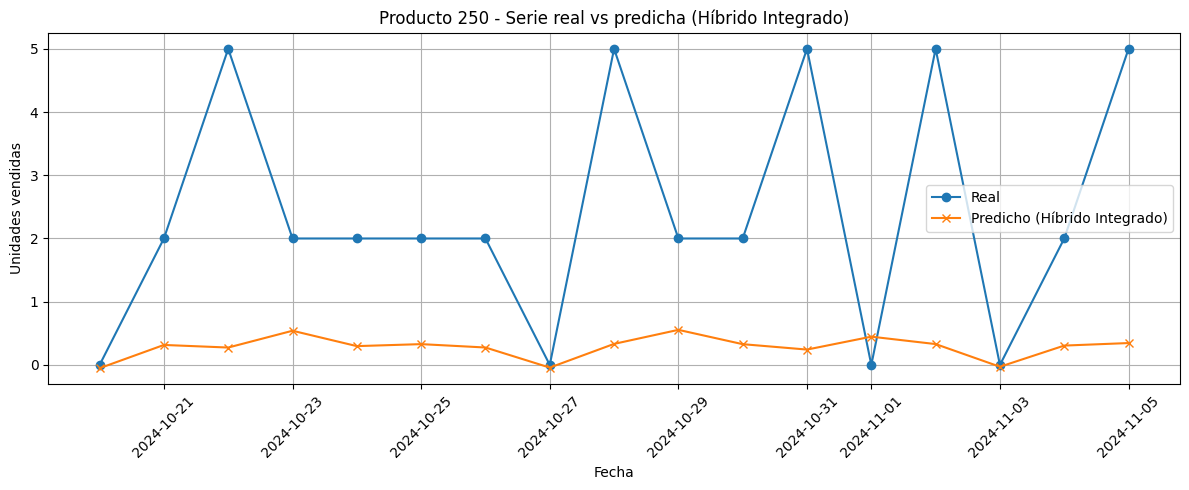

In [64]:
productos_ejemplo = [1, 101, 250] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_integrado[df_resultados_integrado['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Híbrido Integrado)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Híbrido Integrado)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_integrado_producto_{producto_id}.png")
    plt.show()

# 7. Modelo Naive (referencia)

In [176]:

# -----------------------------
# CARGAR BASE Y RESULTADOS ARIMA
# -----------------------------
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df_base[df_base["cluster_kshape"] == 0].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [177]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_599.pkl")

In [74]:
# -----------------------------
# GENERAR MODELO NAIVE
# -----------------------------
resultados_naive = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    
    if len(y_real) < 2:
        continue  # no se puede generar naive

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    fechas = df_prod["idSecuencia"].values[1:]  # desde la 2da fecha
    y_real_recortado = y_real[1:]               # valores reales desde t=2
    y_pred_naive = y_real[:-1]                  # valores anteriores como predicción

    for i in range(len(y_pred_naive)):
        resultados_naive.append({
            "producto": producto_id,
            "fecha": fechas[i],
            "valor_real": y_real_recortado[i],
            "valor_predicho": y_pred_naive[i],
            "modelo": "naive"
        })

In [75]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_naive = pd.DataFrame(resultados_naive)

# Calcular métricas por producto
metricas = df_resultados_naive.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

df_resultados_naive = df_resultados_naive.merge(metricas, on="producto", how="left")

In [76]:
df_resultados_naive.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,1,2024-10-20,0,9,naive,9.671061,7.764706,225.002334
1,1,2024-10-21,14,0,naive,9.671061,7.764706,225.002334
2,1,2024-10-22,14,14,naive,9.671061,7.764706,225.002334
3,1,2024-10-23,5,14,naive,9.671061,7.764706,225.002334
4,1,2024-10-24,24,5,naive,9.671061,7.764706,225.002334


In [77]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
df_resultados_naive.to_csv("predicciones_naive.csv", index=False)
print("Predicciones del modelo naive generadas")


Predicciones del modelo naive generadas


In [178]:
# -----------------------------
# CONSTRUIR RESULTADOS ARIMA (últimos 17 puntos)
# -----------------------------
resultados_arima_list = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])

    # Filtrar a 17 puntos
    if len(y_real) < 17:
        continue

    y_real = y_real[-17:]
    y_pred = y_pred[-17:]

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia").iloc[-len(datos_arima["y_real"]):].reset_index(drop=True)
    fechas = df_prod["idSecuencia"].values[-17:]

    for i in range(17):
        resultados_arima_list.append({
            "producto": producto_id,
            "fecha": fechas[i],
            "valor_real": y_real[i],
            "valor_predicho": y_pred[i],
            "modelo": "arima"
        })

In [179]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_arima = pd.DataFrame(resultados_arima_list)

# Calcular métricas por producto
metricas = df_resultados_arima.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

In [180]:
# Unir métricas al resultado
df_resultados_arima = df_resultados_arima.merge(metricas, on="producto", how="left")

# -----------------------------
# GUARDAR ARCHIVO
# -----------------------------
df_resultados_arima.to_csv("resultados_arima_17.csv", index=False)
print("Resultados de ARIMA generados con 17 puntos")

Resultados de ARIMA generados con 17 puntos


In [181]:
df_resultados_arima.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,1,2024-10-20,0,8.387732,arima,6.801668,5.39884,204.571899
1,1,2024-10-21,14,7.497294,arima,6.801668,5.39884,204.571899
2,1,2024-10-22,14,8.023059,arima,6.801668,5.39884,204.571899
3,1,2024-10-23,5,8.073472,arima,6.801668,5.39884,204.571899
4,1,2024-10-24,24,7.597624,arima,6.801668,5.39884,204.571899


# 8. Análisis de Varianza

In [182]:
# -----------------------------
# CARGAR ARCHIVOS
# -----------------------------
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_arima = pd.read_csv("/kaggle/working/resultados_arima_17.csv")
df_paralelo = pd.read_csv("/kaggle/working/predicciones_ponderado.csv")
df_secuencial = pd.read_csv("/kaggle/working/predicciones_secuencial.csv")
df_integrado = pd.read_csv("/kaggle/working/resultados_modelo_integrado.csv")
df_lstm_general = pd.read_csv("/kaggle/working/predicciones_lstm_general.csv")

## 8.1. Preparar los datos

In [183]:
# -----------------------------
# FILTRAR 17 ÚLTIMOS PUNTOS DE CADA MODELO
# -----------------------------
def filtrar_ultimos_17(df, nombre_modelo):
    df = df.copy()
    df = df.sort_values(["producto", "fecha"])
    df["rank"] = df.groupby("producto")["fecha"].rank(method="first", ascending=False)
    df = df[df["rank"] <= 17].copy()
    df["modelo"] = nombre_modelo
    return df.drop(columns=["rank"])

df_naive = filtrar_ultimos_17(df_naive, "naive")
df_arima = filtrar_ultimos_17(df_arima, "arima")
df_paralelo = filtrar_ultimos_17(df_paralelo, "paralelo")
df_secuencial = filtrar_ultimos_17(df_secuencial, "secuencial")
df_integrado = filtrar_ultimos_17(df_integrado, "integrado")
df_lstm_general = filtrar_ultimos_17(df_lstm_general, "lstm")

In [184]:
# Renombrar columnas en df_lstm
df_lstm_general.rename(columns={
    "valor_real": "valor_real",
    "valor_predicho": "valor_predicho",
    "metodo":"modelo"
}, inplace=True)

In [185]:
metricas_lstm = df_lstm_general.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

In [186]:
df_lstm_general = df_lstm_general.merge(metricas_lstm, on="producto", how="left")

In [187]:
# -----------------------------
# UNIFICAR ESTRUCTURA
# -----------------------------
def estandarizar_columnas(df, nombre_modelo):
    df = df.copy()
    df["modelo"] = nombre_modelo
    columnas_requeridas = ["producto", "fecha", "valor_real", "valor_predicho", "modelo", "rmse", "mae", "mape"]
    for col in ["rmse", "mae", "mape"]:
        if col not in df.columns:
            df[col] = None  # se calcularán después si no existen
    return df[columnas_requeridas]

df_naive = estandarizar_columnas(df_naive, "naive")
df_arima = estandarizar_columnas(df_arima, "arima")
df_paralelo = estandarizar_columnas(df_paralelo, "paralelo")
df_secuencial = estandarizar_columnas(df_secuencial, "secuencial")
df_integrado = estandarizar_columnas(df_integrado, "integrado")
df_lstm_general = estandarizar_columnas(df_integrado, "lstm")

In [189]:
# -----------------------------
# UNIR TODOS LOS MODELOS
# -----------------------------
df_comparacion = pd.concat([
    df_naive,
    df_arima,
    df_paralelo,
    df_secuencial,
    df_integrado,
    df_lstm_general
], ignore_index=True)

# -----------------------------
# GUARDAR ARCHIVO FINAL
# -----------------------------
df_comparacion.to_csv("/kaggle/working/resultados_comparacion_modelos.csv", index=False)
print("Archivo unificado generado")

Archivo unificado generado


## 8.2 Verificar supuestos de ANOVA

In [190]:
# -----------------------------
# VERIFICAR NORMALIDAD POR MODELO (KOLMOGOROV-SMIRNOV)
# -----------------------------
print("Test de normalidad (Kolmogorov-Smirnov) por modelo:")
normalidad = {}
for modelo in df_comparacion["modelo"].unique():
    x = df_comparacion[df_comparacion["modelo"] == modelo]["rmse"]
    stat, p = kstest(x, "norm", args=(x.mean(), x.std()))
    normalidad[modelo] = p
    print(f" - {modelo}: p-valor = {p:.4f} {'(Normal)' if p > 0.05 else 'No normal'}")


Test de normalidad (Kolmogorov-Smirnov) por modelo:
 - naive: p-valor = 0.0000 No normal
 - arima: p-valor = 0.0000 No normal
 - paralelo: p-valor = 0.0000 No normal
 - secuencial: p-valor = 0.0000 No normal
 - integrado: p-valor = 0.0000 No normal
 - lstm: p-valor = 0.0000 No normal


In [191]:
# -----------------------------
# VERIFICAR HOMOGENEIDAD DE VARIANZAS (LEVENE)
# -----------------------------
print("Test de homogeneidad de varianzas (Levene):")
grupos_rmse = [g["rmse"].values for _, g in df_comparacion.groupby("modelo")]
stat_levene, p_levene = levene(*grupos_rmse)
print(f" - p-valor Levene = {p_levene:.4f} {'(Homogénea)' if p_levene > 0.05 else 'No homogénea'}")


Test de homogeneidad de varianzas (Levene):
 - p-valor Levene = 0.0000 No homogénea


## 8.3 Aplicar el test no parametrico  Kruskal-Wallis

In [192]:
print("Prueba comparativa entre modelos:")
stat_kw, p_kw = kruskal(*grupos_rmse)
print(f" Kruskal-Wallis aplicado: p-valor = {p_kw:.4f}")

Prueba comparativa entre modelos:
 Kruskal-Wallis aplicado: p-valor = 0.0000


In [193]:
# -----------------------------
# APLICAR DUNN'S TEST POST-HOC (con corrección de Holm)
# -----------------------------
print("Prueba post-hoc de Dunn (corrección de Holm) sobre RMSE:")
dunn_result = sp.posthoc_dunn(
    df_comparacion, 
    val_col='rmse', 
    group_col='modelo', 
    p_adjust='holm'
)

print(dunn_result)

Prueba post-hoc de Dunn (corrección de Holm) sobre RMSE:
                   arima      integrado           lstm          naive  \
arima       1.000000e+00   2.858226e-47   2.858226e-47   0.000000e+00   
integrado   2.858226e-47   1.000000e+00   1.000000e+00  2.302994e-153   
lstm        2.858226e-47   1.000000e+00   1.000000e+00  2.302994e-153   
naive       0.000000e+00  2.302994e-153  2.302994e-153   1.000000e+00   
paralelo    1.724541e-27  5.974861e-143  5.974861e-143   0.000000e+00   
secuencial  3.428488e-01   4.259692e-39   4.259692e-39   0.000000e+00   

                 paralelo    secuencial  
arima        1.724541e-27  3.428488e-01  
integrado   5.974861e-143  4.259692e-39  
lstm        5.974861e-143  4.259692e-39  
naive        0.000000e+00  0.000000e+00  
paralelo     1.000000e+00  2.474475e-34  
secuencial   2.474475e-34  1.000000e+00  


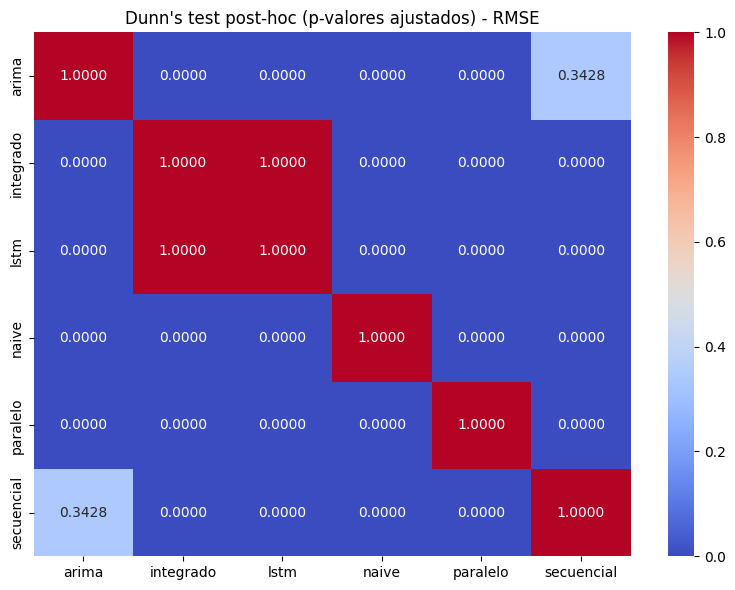

In [194]:
# -----------------------------
# VISUALIZAR MATRIZ DE P-VALORES
# -----------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".4f", cmap="coolwarm", cbar=True)
plt.title("Dunn's test post-hoc (p-valores ajustados) - RMSE")
plt.tight_layout()
plt.savefig("dunn_test_rmse_heatmap.png")
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <ul>
        <li>Se aplicó la prueba no paramétrica de Kruskal-Wallis, seguida de un test post-hoc de Dunn con corrección de Holm.</li>
        <li>Los resultados mostraron diferencias significativas entre los modelos (p < 0.001).</li>
        <li>El modelo híbrido integrado y la red LSTM general obtuvieron los menores errores (RMSE) y no presentaron diferencias significativas entre sí (p = 1.000), mientras que ambos superaron significativamente al modelo naive, al híbrido secuencial y al híbrido paralelo</li>
    </ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>En los productos regulares, el modelo LSTM puede tener un comportamiento tan bueno como el  modelo híbrido integrado, y por eso empatan. El beneficio de los modelos híbridos podrían ser más claro en los productos irregulares, donde la combinación de estructuras aporta más.</strong></li> 
</ul>
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Limitación:</strong>
    <p>A pesar de contar con series temporales de más de 700 registros por producto, la decisión metodológica de aplicar <strong></strong>ARIMA para un horizonte de 18 días</stong>, alineado con el ciclo de aprovisionamiento, restringe la cantidad de residuos disponibles para los modelos híbridos. </p>
    <p>Esta limitación afecta a la cantidad de ejemplos de entrenamiento para la red LSTM y condiciona a la arquitectura a trabajar con ventanas cortas (n_lags = 1) ya que se debe conservar la equivalencia en el número de puntos comparables entre modelos.</p>
</div>

# 9. Mejor predicción por producto y fecha según RMSE del modelo

In [4]:
# -----------------------------
# CARGAR ARCHIVO UNIFICADO
# -----------------------------
df_comparacion = pd.read_csv("/kaggle/working/resultados_comparacion_modelos.csv")

In [8]:
# -----------------------------
# IDENTIFICAR EL MEJOR MODELO POR PRODUCTO (basado en menor RMSE)
# -----------------------------
# Obtener el modelo con menor RMSE por producto
mejores_modelos = df_comparacion.groupby("producto")["rmse"].idxmin()
df_mejores = df_comparacion.loc[mejores_modelos, ["producto", "modelo", "rmse"]].reset_index(drop=True)

# -----------------------------
# UNIR PARA TOMAR LA PREDICCIÓN COMPLETA DE ESE MODELO
# -----------------------------
df_pred_mejor = pd.merge(
    df_comparacion,
    df_mejores,
    on=["producto", "modelo", "rmse"],
    how="inner"
)[["producto", "fecha", "valor_real", "valor_predicho", "rmse", "modelo"]]

# Renombrar columna para claridad
df_pred_mejor.rename(columns={"valor_predicho": "mejor_pronostico"}, inplace=True)

In [10]:
df_pred_mejor.tail()

,producto,fecha,valor_real,mejor_pronostico,rmse,modelo
10178,999,2024-11-01,0.0,0.108509,1.721742,integrado
10179,999,2024-11-02,0.0,0.334772,1.721742,integrado
10180,999,2024-11-03,0.0,-0.006257,1.721742,integrado
10181,999,2024-11-04,0.0,0.295223,1.721742,integrado
10182,999,2024-11-05,0.0,0.255222,1.721742,integrado


In [11]:
# -----------------------------
# GUARDAR RESULTADO
# -----------------------------
df_pred_mejor.to_csv("/kaggle/working/mejor_pronostico_por_producto.csv", index=False)
print("Archivo generado con las mejores predicciones por producto.")


Archivo generado con las mejores predicciones por producto.


In [12]:
# -----------------------------
# ELIMINAR DUPLICADOS POR PRODUCTO (una fila por serie)
# -----------------------------
df_modelo_unico = df_pred_mejor.drop_duplicates(subset=["producto"])

# -----------------------------
# CALCULAR FRECUENCIA PORCENTUAL POR MODELO
# -----------------------------
frecuencia = (
    df_modelo_unico["modelo"]
    .value_counts(normalize=True)
    .rename("frecuencia_porcentual")
    .reset_index()
    .rename(columns={"index": "modelo"})
)

frecuencia["frecuencia_porcentual"] = frecuencia["frecuencia_porcentual"] * 100


In [13]:
frecuencia

,modelo,frecuencia_porcentual
0,paralelo,74.958264
1,integrado,14.691152
2,secuencial,4.340568
3,arima,4.173623
4,naive,1.836394


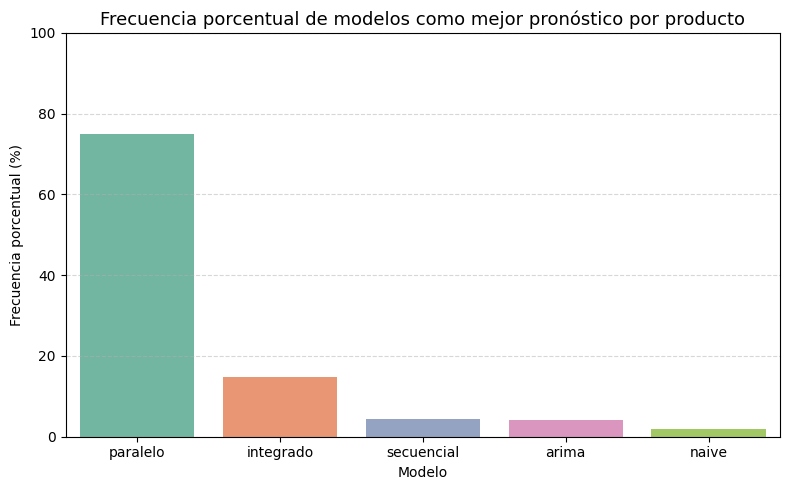

In [14]:
# -----------------------------
# GRAFICO DE BARRAS
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=frecuencia, x="modelo", y="frecuencia_porcentual", palette="Set2")
plt.title("Frecuencia porcentual de modelos como mejor pronóstico por producto", fontsize=13)
plt.ylabel("Frecuencia porcentual (%)")
plt.xlabel("Modelo")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("frecuencia_modelos_mejor_pronostico.png")
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>Un hallazgo particularmente interesante surgió al analizar la frecuencia con la que cada modelo fue seleccionado como el mejor predictor por producto. A pesar de que el modelo LSTM general obtuvo un desempeño competitivo en términos de métricas promedio, no logró destacarse como el mejor modelo en ningún producto individual, según el criterio de menor RMSE.</p> 
    <p>En contraste, el modelo híbrido paralelo fue el más efectivo en el 74.96% de los casos, lo que evidencia una alta consistencia a nivel individual.</p>
    <p> Este resultado sugiere que el enfoque de combinación ponderada de ARIMA y LSTM en paralelo no solo ofrece robustez global, sino también una capacidad superior de adaptación a las particularidades de cada serie. La LSTM, al estar entrenada de forma generalizada para todos los productos, parece perder precisión frente a modelos que incorporan estructura lineal (como ARIMA) y aprovechan información contextual específica. </p>
    <p>Este contraste refuerza la importancia de evaluar el rendimiento no solo con promedios agregados, sino también considerando la precisión a nivel desagregado (producto a producto), donde los modelos híbridos muestran un valor diferencial significativo.</p>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>El análisis de varianza confirmó diferencias globales en desempeño. Sin embargo, al analizar producto por producto, observamos que el modelo híbrido paralelo fue el mejor en el 75% de los casos, mostrando una fortaleza distinta: <strong>la consistencia individual</strong>.</li> 
</ul>
</div>

# 10. Impacto económico del mejor modelo

In [6]:
# -----------------------------
# Cargar archivos
# -----------------------------
df_mejor = pd.read_csv("/kaggle/working/mejor_pronostico_por_producto.csv")
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_aprovisionamiento = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosCicloAprovisionamiento.xlsx")
df_precios = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosPrecioMedio.xlsx")

In [43]:
# 1. Obtener RMSE por producto del mejor modelo
resumen_mejor = df_mejor.groupby("producto").agg({
    "rmse": "mean",
    "modelo": "first"
}).reset_index()
resumen_mejor.rename(columns={"rmse": "rmse_mejor"}, inplace=True)

In [44]:
# 2. Obtener RMSE por producto del naive
rmse_naive = df_naive.groupby("producto")["rmse"].mean().reset_index()
rmse_naive.rename(columns={"rmse": "rmse_naive"}, inplace=True)

In [45]:
# 3. Calcular ciclo de aprovisionamiento
df_aprovisionamiento["aprovisionamiento"] = df_aprovisionamiento["diasEntrePedidos"] + df_aprovisionamiento["diasLeadtime"]

In [46]:
# 4. Merge de toda la información
df = pd.merge(resumen_mejor, rmse_naive, on="producto")
df = pd.merge(df, df_aprovisionamiento[["producto", "aprovisionamiento"]], on="producto")
df = pd.merge(df, df_precios[["producto", "eurPrecioMedio"]], on="producto")

In [47]:
# -----------------------------
# Cálculos de stock y económico
# -----------------------------

valor_z = 1.645  # Valor Z para 95% de confianza
porcentaje_coste = 0.05  # 5% de coste de mantenimiento

# Stock en unidades
df["udsStock_naive"] = valor_z * df["rmse_naive"] * np.sqrt(df["aprovisionamiento"])
df["udsStock_mejor"] = valor_z * df["rmse_mejor"] * np.sqrt(df["aprovisionamiento"])

# Coste del stock (5% del valor)
df["coste_udsStock_naive"] = df["udsStock_naive"] * df["eurPrecioMedio"] * porcentaje_coste
df["coste_udsStock_mejor"] = df["udsStock_mejor"] * df["eurPrecioMedio"] * porcentaje_coste

# Coste anual 
df["coste_anual_naive"] = df["coste_udsStock_naive"] * 365
df["coste_anual_mejor"] = df["coste_udsStock_mejor"] * 365

# Ahorro
df["ahorro_unidades"] = df["udsStock_naive"] - df["udsStock_mejor"]
df["ahorro_coste_stock"] = df["coste_anual_naive"] - df["coste_anual_mejor"]

In [48]:
df.head()

,producto,rmse_mejor,modelo,rmse_naive,aprovisionamiento,eurPrecioMedio,udsStock_naive,udsStock_mejor,coste_udsStock_naive,coste_udsStock_mejor,coste_anual_naive,coste_anual_mejor,ahorro_unidades,ahorro_coste_stock
0,1,5.845818,paralelo,9.671061,29,68.730000,85.672019,51.785736,294.411894,177.961683,107460.341258,64956.014205,33.886283,42504.327053
1,2,4.128580,paralelo,8.011022,29,148.330000,70.966407,36.573427,526.322355,271.246820,192107.659700,99005.089457,34.392980,93102.570242
2,3,4.209257,paralelo,5.029326,29,169.000000,44.552766,37.288108,376.470870,315.084515,137411.867435,115005.847962,7.264657,22406.019474
3,4,2.805466,paralelo,2.869720,29,0.604383,25.421692,24.852492,0.768222,0.751021,280.400981,274.122704,0.569201,6.278278
4,5,2.849367,paralelo,3.702146,29,4.553314,32.795813,25.241388,7.466482,5.746599,2725.265998,2097.508538,7.554425,627.757460


In [51]:
# -----------------------------
# Resultados agregados
# -----------------------------
total_coste_naive = df["coste_anual_naive"].sum()
total_coste_mejor = df["coste_anual_mejor"].sum()
total_ahorro = df["ahorro_coste_stock"].sum()
porcentaje_ahorro = 100 * total_ahorro / df["coste_anual_naive"].sum()

print(f"Coste total de stock naive: {total_coste_naive:.2f} €")
print(f"Coste total de stock mejor: {total_coste_mejor:.2f} €")
print(f"Ahorro económico anual estimado: {total_ahorro:.2f} €")
print(f"Porcentaje de ahorro respecto al Naive: {porcentaje_ahorro:.2f}%")

Coste total de stock naive: 12742227.61 €
Coste total de stock mejor: 7992166.47 €
Ahorro económico anual estimado: 4750061.13 €
Porcentaje de ahorro respecto al Naive: 37.28%


In [52]:
# -----------------------------
# Guardar resumen
# -----------------------------
df.to_csv("impacto_economico.csv", index=False)
print("Archivo generado.")

Archivo generado.


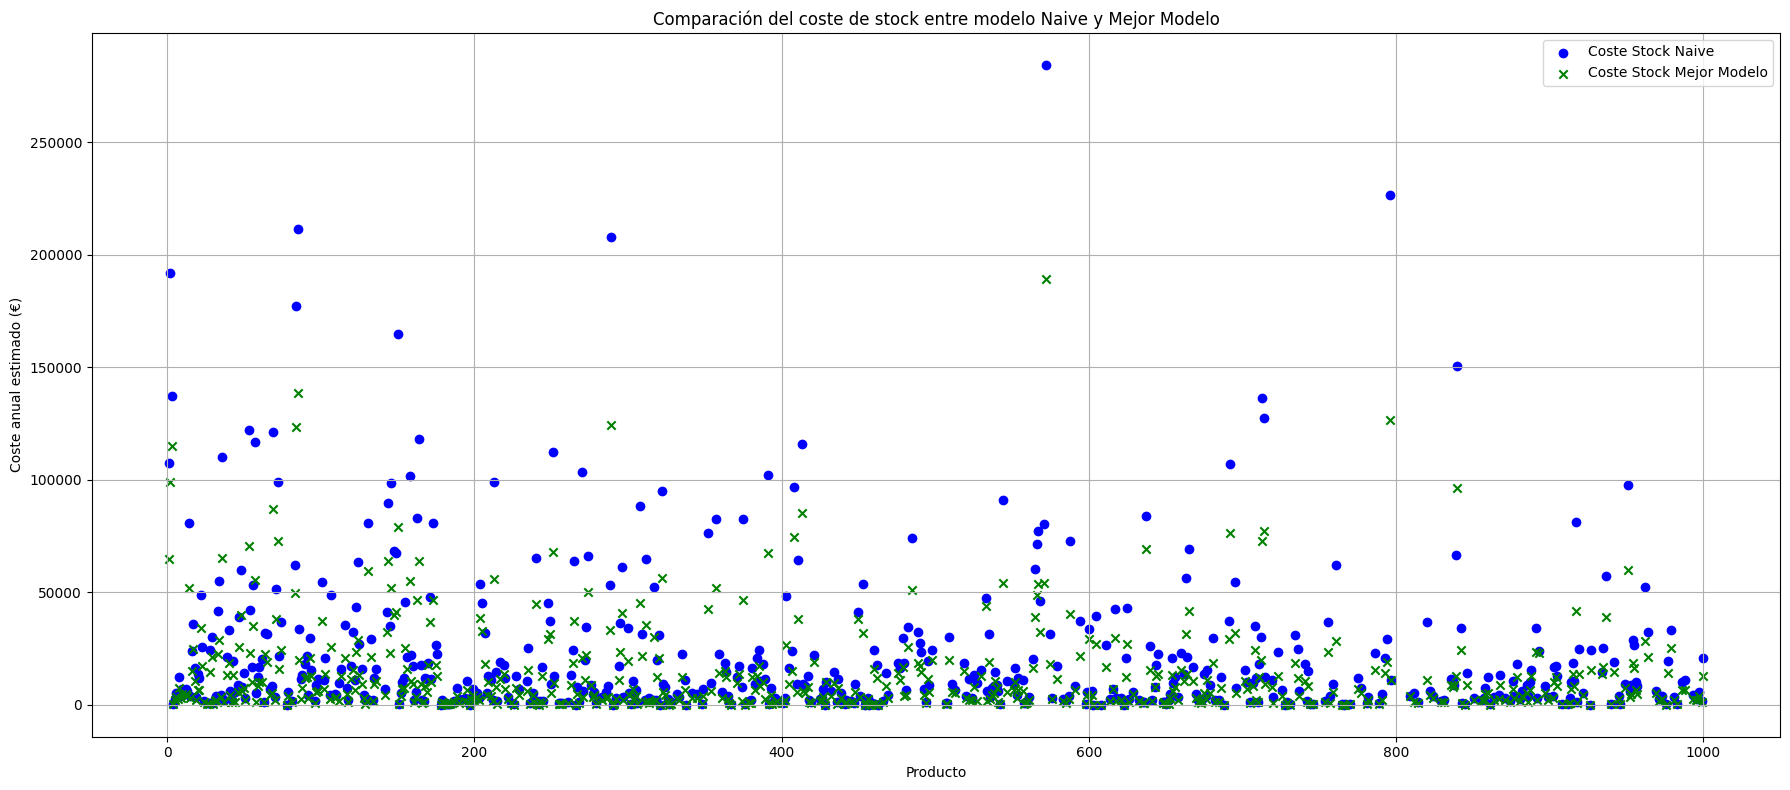

In [59]:
# -----------------------------
# Ordenar productos para el gráfico
# -----------------------------
df_sorted = df.sort_values("producto").reset_index(drop=True)

# -----------------------------
# Graficar coste_stock naive vs mejor
# -----------------------------
plt.figure(figsize=(18, 8))

# Scatter para Naive
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_naive'], label='Coste Stock Naive', marker='o', color='blue')

# Scatter para Mejor Modelo
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_mejor'], label='Coste Stock Mejor Modelo', marker='x', color='green')

plt.title("Comparación del coste de stock entre modelo Naive y Mejor Modelo")
plt.xlabel("Producto")
plt.ylabel("Coste anual estimado (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/lineplot_coste_stock_comparativo.png")
plt.show()